# t-statistics from scratch: theory, synthetic examples, real data

A $t$-statistic answers one question: **how many standard errors is my estimate away
from the value I would expect if nothing were going on?**

$$t = \frac{\hat\theta - \theta_0}{\widehat{\text{SE}}(\hat\theta)}$$

Everything else (the $t$ distribution, degrees of freedom, p-values, the different
tests) is about how to judge that number honestly.

**What's in here**

Part 1, theory
1. the statistic, and the $z$ version when $\sigma$ is known
2. why replacing $\sigma$ by $s$ produces the $t$ distribution (built from its parts)
3. degrees of freedom
4. critical values, p-values, one- vs two-sided
5. assumptions, and what breaks them
6. the family: one-sample, paired, two-sample (pooled, Welch), regression coefficient, correlation, Sharpe

Part 2, synthetic examples (by hand, then SciPy, then simulation of size and power)
7. one-sample: "is the mean return positive?"
8. two-sample: pooled vs Welch and when pooled is wrong
9. paired: comparing two models on the same days
10. regression coefficient and correlation
11. non-normal data: how small can $n$ be?
12. autocorrelation: the assumption that fails most often on time series
13. the Sharpe ratio as a $t$-statistic

Part 3, real hourly power data
14. mean price change, weekend effect, model comparison, temperature coefficient, wind–price correlation

Prerequisite: `03_scipy/00_stats_intro_from_scratch.ipynb` (standard errors, autocorrelation, regression SEs).

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

# Part 1 — Theory

## 1. The statistic, and the $z$ version

Take $n$ independent observations with mean $\mu$ and standard deviation $\sigma$. The
sample mean $\bar x$ has standard error $\sigma/\sqrt n$. If $\sigma$ were **known**,

$$z = \frac{\bar x - \mu_0}{\sigma/\sqrt n}$$

would be exactly standard normal under $H_0: \mu = \mu_0$ (for normal data; approximately
for anything else once $n$ is moderate, by the central limit theorem). Then
$P(|z| > 1.96) = 0.05$, and the rest is bookkeeping.

Check it: 20,000 samples of $n = 8$ from $N(0, 2^2)$, compute $z$ with the **true**
$\sigma = 2$.

In [2]:
n, sigma = 8, 2.0
samples = rng.normal(0, sigma, size=(20_000, n))
z = samples.mean(axis=1) / (sigma / np.sqrt(n))
print("sd of z             :", round(z.std(), 3), " (should be 1)")
print("P(|z| > 1.96)       :", round((np.abs(z) > 1.96).mean(), 4), " (should be 0.05)")

sd of z             : 1.003  (should be 1)
P(|z| > 1.96)       : 0.0509  (should be 0.05)


## 2. Why the $t$ distribution: $\sigma$ is not known

In practice $\sigma$ is replaced by the sample standard deviation $s$:

$$t = \frac{\bar x - \mu_0}{s/\sqrt n}$$

$s$ is itself random: in a sample where the points happen to sit close together, $s$ is
small, the denominator is small, and $t$ is inflated. So $t$ has **heavier tails** than
$z$, more so for small $n$ where $s$ is noisier.

The exact distribution comes from three facts about normal data:

1. $Z = \dfrac{\bar x - \mu}{\sigma/\sqrt n} \sim N(0,1)$
2. $V = \dfrac{(n-1)s^2}{\sigma^2} \sim \chi^2_{n-1}$ (a sum of $n-1$ squared standard normals)
3. $\bar x$ and $s^2$ are independent (a special property of the normal)

Dividing top and bottom of $t$ by $\sigma/\sqrt n$:

$$t = \frac{(\bar x-\mu)/(\sigma/\sqrt n)}{s/\sigma} = \frac{Z}{\sqrt{V/(n-1)}}$$

A standard normal divided by the square root of an independent $\chi^2_\nu/\nu$ is, by
definition, **Student's $t$ with $\nu$ degrees of freedom**. Build it from the parts and
compare with the $t$ computed directly from samples: same distribution.

In [3]:
nu = n - 1
Z = rng.normal(0, 1, 20_000)
V = rng.chisquare(nu, 20_000)
t_from_parts = Z / np.sqrt(V / nu)
t_direct = samples.mean(axis=1) / (samples.std(axis=1, ddof=1) / np.sqrt(n))
print("sd of t (parts) :", round(t_from_parts.std(), 3), "  sd of t (direct):", round(t_direct.std(), 3),
      "  theory sqrt(nu/(nu-2)) =", round(np.sqrt(nu / (nu - 2)), 3))
print("P(|t| > 1.96) parts :", round((np.abs(t_from_parts) > 1.96).mean(), 4),
      "  direct:", round((np.abs(t_direct) > 1.96).mean(), 4), "  <- more than 5%: the normal threshold is wrong at n=8")

sd of t (parts) : 1.18   sd of t (direct): 1.183   theory sqrt(nu/(nu-2)) = 1.183
P(|t| > 1.96) parts : 0.0895   direct: 0.0888   <- more than 5%: the normal threshold is wrong at n=8


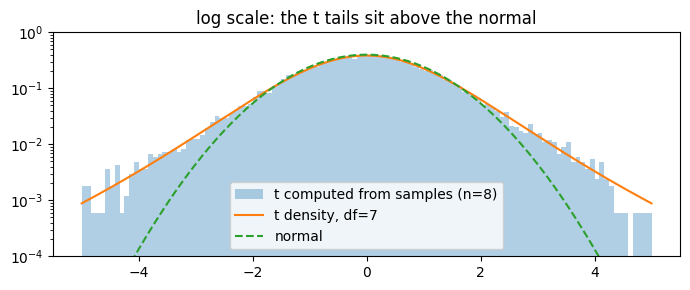

In [4]:
grid = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(t_direct, bins=120, range=(-5, 5), density=True, alpha=.35, label="t computed from samples (n=8)")
ax.plot(grid, stats.t.pdf(grid, df=nu), label=f"t density, df={nu}")
ax.plot(grid, stats.norm.pdf(grid), "--", label="normal")
ax.set_yscale("log"); ax.set_ylim(1e-4, 1); ax.legend(); ax.set_title("log scale: the t tails sit above the normal")
plt.tight_layout()

The log scale makes the tail difference visible: at $|t| = 4$ the $t_7$ density is
about ten times the normal density. As $\nu \to \infty$, $s \to \sigma$ and $t \to z$.

In [5]:
rows = []
for df_ in [1, 2, 3, 5, 10, 30, 100, np.inf]:
    dist = stats.norm if df_ == np.inf else stats.t(df=df_)
    rows.append({"df": df_, "P(|t| > 2)": 2 * dist.sf(2), "critical value (2-sided 5%)": dist.ppf(0.975), "P(|t| > 1.96)": 2 * dist.sf(1.96)})
pd.DataFrame(rows).round(4)

,df,P(|t| > 2),critical value (2-sided 5%),P(|t| > 1.96)
0,1.0,0.2952,12.7062,0.3003
1,2.0,0.1835,4.3027,0.1891
2,3.0,0.1393,3.1824,0.1449
3,5.0,0.1019,2.5706,0.1073
4,10.0,0.0734,2.2281,0.0784
5,30.0,0.0546,2.0423,0.0593
6,100.0,0.0482,1.9840,0.0528
7,inf,0.0455,1.9600,0.0500


With 5 degrees of freedom you need $|t| > 2.57$ for 5% significance, not 1.96. With 30
or more the difference is small, which is why "$t > 2$" is the usual rule of thumb.

## 3. Degrees of freedom

Why $n - 1$? The deviations $x_i - \bar x$ always sum to zero, so once $n-1$ of them
are known the last is fixed: only $n-1$ of them carry information about $\sigma$. In
general, degrees of freedom $= n - $ (number of parameters estimated from the data
before computing the residuals): $n-1$ for a mean, $n-2$ for a simple regression,
$n-p-1$ for $p$ regressors.

See it: for $n = 3$ the three deviations always sum to zero.

In [6]:
for _ in range(3):
    xs = rng.normal(0, 1, 3).round(3)
    dev = (xs - xs.mean()).round(3)
    print("x:", xs, " deviations:", dev, " sum of deviations:", round(dev.sum(), 10))

x: [ 0.269  0.023 -1.235]  deviations: [ 0.583  0.337 -0.921]  sum of deviations: -0.001
x: [ 0.05  -1.787 -1.548]  deviations: [ 1.145 -0.692 -0.453]  sum of deviations: 0.0
x: [-0.151 -0.856  0.038]  deviations: [ 0.172 -0.533  0.361]  sum of deviations: -0.0


## 4. Critical values, p-values, one- and two-sided

- **Critical value**: the threshold $t$ must exceed for a given significance level.
  `stats.t.ppf(1 - alpha/2, df)` for two-sided, `stats.t.ppf(1 - alpha, df)` for one-sided.
- **p-value**: the probability under $H_0$ of a statistic at least as extreme as observed.
  Two-sided: $2\,P(T_\nu > |t|)$ = `2 * stats.t.sf(abs(t), df)`. One-sided ($H_1: \mu > \mu_0$): `stats.t.sf(t, df)`.
- The two are the same information: $p < \alpha \iff |t| > $ critical value.

**Rule:** decide one- or two-sided *before* seeing the data. "Is the return positive?"
is one-sided; "is the coefficient different from zero?" is two-sided. Switching to
one-sided after seeing the sign halves the p-value dishonestly.

In [7]:
t_obs, df_ = 2.2, 9
print("two-sided critical (5%) :", round(stats.t.ppf(0.975, df_), 3), " reject:", abs(t_obs) > stats.t.ppf(0.975, df_))
print("one-sided critical (5%) :", round(stats.t.ppf(0.95, df_), 3), " reject:", t_obs > stats.t.ppf(0.95, df_))
print("two-sided p             :", round(2 * stats.t.sf(abs(t_obs), df_), 4))
print("one-sided p             :", round(stats.t.sf(t_obs, df_), 4))

two-sided critical (5%) : 2.262  reject: False
one-sided critical (5%) : 1.833  reject: True
two-sided p             : 0.0553
one-sided p             : 0.0277


## 5. Assumptions, and what breaks them

| Assumption | Why it is needed | What happens when it fails | Fix |
|---|---|---|---|
| observations are **independent** | the SE formula $s/\sqrt n$ uses $\operatorname{Var}(\sum x_i) = \sum \operatorname{Var}(x_i)$ | autocorrelated data: SE too small, $t$ too large, false positives | effective $n$, Newey–West SE, aggregate to a coarser frequency, block bootstrap (section 12) |
| data roughly normal, **or** $n$ large enough | the exact $t$ distribution assumes normal data; CLT rescues the mean otherwise | heavy tails / skew at small $n$: wrong size | larger $n$, permutation test, bootstrap, rank test (section 11) |
| two-sample: equal variances (pooled version only) | pooled $s_p$ mixes the two | unequal variances with unequal $n$: wrong size | Welch's $t$ (section 8) |
| no outliers driving $\bar x$ | one huge value dominates both $\bar x$ and $s$ | $t$ can be either inflated or deflated | look at the data; robust or rank alternatives |

Independence is the one that matters most for a quant, and it is the one the software
never checks for you.

## 6. The family of $t$-statistics

| Test | $\hat\theta$ | $\widehat{\text{SE}}$ | df | SciPy |
|---|---|---|---|---|
| one-sample mean | $\bar x - \mu_0$ | $s/\sqrt n$ | $n-1$ | `ttest_1samp(x, mu0)` |
| paired (two measurements per unit) | $\bar d$, $d_i = a_i - b_i$ | $s_d/\sqrt n$ | $n-1$ | `ttest_rel(a, b)` |
| two-sample, pooled | $\bar a - \bar b$ | $s_p\sqrt{1/n_a + 1/n_b}$, $s_p^2 = \frac{(n_a-1)s_a^2 + (n_b-1)s_b^2}{n_a+n_b-2}$ | $n_a+n_b-2$ | `ttest_ind(a, b)` |
| two-sample, Welch | $\bar a - \bar b$ | $\sqrt{s_a^2/n_a + s_b^2/n_b}$ | Welch–Satterthwaite (below) | `ttest_ind(a, b, equal_var=False)` |
| regression slope | $\hat b$ | $\hat\sigma/\sqrt{S_{xx}}$ | $n-2$ | `linregress(x, y)` |
| correlation | $r$ | $\sqrt{(1-r^2)/(n-2)}$, i.e. $t = r\sqrt{n-2}/\sqrt{1-r^2}$ | $n-2$ | `pearsonr(x, y)` |
| Sharpe ratio | $\text{SR} = \bar r / s$ | $1/\sqrt T$ (approx.) | $T-1$ | (one-sample test on returns) |

Welch degrees of freedom:
$\nu = \dfrac{(s_a^2/n_a + s_b^2/n_b)^2}{\dfrac{(s_a^2/n_a)^2}{n_a-1} + \dfrac{(s_b^2/n_b)^2}{n_b-1}}$
(a non-integer; SciPy handles it).

# Part 2 — Synthetic examples

## 7. One-sample: "is the mean return positive?"

100 daily returns with true mean 0.15 and sd 1. By hand, then SciPy.

In [8]:
r = rng.normal(0.15, 1.0, 100)
n = len(r)
xbar, s = r.mean(), r.std(ddof=1)
se = s / np.sqrt(n)
t_stat = (xbar - 0) / se
p_one = stats.t.sf(t_stat, df=n - 1)
print("mean :", round(xbar, 4), " s :", round(s, 4), " SE :", round(se, 4))
print("t    :", round(t_stat, 4), " one-sided p :", round(p_one, 4))
res = stats.ttest_1samp(r, 0, alternative="greater")
print("scipy:", round(res.statistic, 4), round(res.pvalue, 4))

mean : 0.1456  s : 0.9563  SE : 0.0956
t    : 1.523  one-sided p : 0.0655
scipy: 1.523 0.0655


**Size**: repeat under $H_0$ (true mean 0) and count rejections at 5%; should be 5%.
**Power**: repeat under the alternative (true mean 0.15) and count rejections; that is
the probability of detecting the effect. Then the power curve against $n$.

In [9]:
def one_sample_reject(true_mean, n, sims=4000, alpha=0.05):
    x = rng.normal(true_mean, 1.0, size=(sims, n))
    t = x.mean(axis=1) / (x.std(axis=1, ddof=1) / np.sqrt(n))
    return (t > stats.t.ppf(1 - alpha, df=n - 1)).mean()

print("size  (true mean 0,    n=100):", round(one_sample_reject(0.0, 100), 3))
print("power (true mean 0.15, n=100):", round(one_sample_reject(0.15, 100), 3))

size  (true mean 0,    n=100): 0.046
power (true mean 0.15, n=100): 0.452


,n,power
0,10,0.124
1,25,0.180
2,50,0.290
3,100,0.440
4,200,0.683
5,400,0.913
6,800,0.996


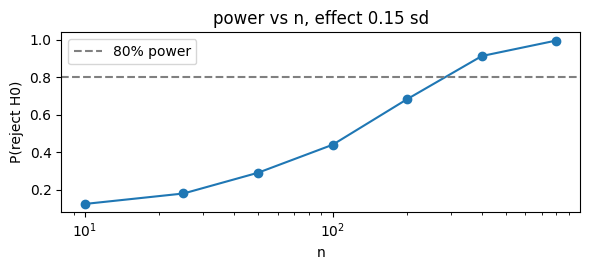

In [10]:
ns = [10, 25, 50, 100, 200, 400, 800]
power = [one_sample_reject(0.15, n_) for n_ in ns]
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(ns, power, "o-"); ax.axhline(0.8, ls="--", color="grey", label="80% power")
ax.set_xscale("log"); ax.set_xlabel("n"); ax.set_ylabel("P(reject H0)"); ax.set_title("power vs n, effect 0.15 sd"); ax.legend()
plt.tight_layout()
pd.DataFrame({"n": ns, "power": power}).round(3)

Rule of thumb hidden in that curve: to detect an effect of $d$ standard deviations with
80% power (one-sided, 5%) you need roughly $n \approx (2.5/d)^2$. For $d = 0.15$ that
is about 280 observations. A daily Sharpe of 0.15 is an annual Sharpe of 2.4, and it
still takes over a year of daily data to confirm at 80% power.

**Interview check:** "What is the power of your test?" is the question behind "you
found nothing; does that mean there is nothing?"

## 8. Two-sample: pooled vs Welch

Are the returns in regime A different from regime B? Two independent samples.

In [11]:
a = rng.normal(0.3, 1.0, 30)
b = rng.normal(0.0, 1.0, 40)
na, nb = len(a), len(b)
diff = a.mean() - b.mean()
sp2 = ((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2)
se_pooled = np.sqrt(sp2 * (1 / na + 1 / nb))
t_pooled = diff / se_pooled
print("difference of means :", round(diff, 4))
print("pooled s_p^2        :", round(sp2, 4), " SE pooled:", round(se_pooled, 4))
print("t pooled            :", round(t_pooled, 4), " df:", na + nb - 2, " p:", round(2 * stats.t.sf(abs(t_pooled), na + nb - 2), 4))
print("scipy pooled        :", stats.ttest_ind(a, b))

difference of means : 0.1088
pooled s_p^2        : 0.946  SE pooled: 0.2349
t pooled            : 0.4633  df: 68  p: 0.6446
scipy pooled        : TtestResult(statistic=0.463301148561326, pvalue=0.6446279882976758, df=68.0)


In [12]:
va, vb = a.var(ddof=1) / na, b.var(ddof=1) / nb
se_welch = np.sqrt(va + vb)
df_welch = (va + vb) ** 2 / (va ** 2 / (na - 1) + vb ** 2 / (nb - 1))
t_welch = diff / se_welch
print("SE Welch :", round(se_welch, 4), " df Welch:", round(df_welch, 2), " t:", round(t_welch, 4), " p:", round(2 * stats.t.sf(abs(t_welch), df_welch), 4))
print("scipy Welch:", stats.ttest_ind(a, b, equal_var=False))

SE Welch : 0.2287  df Welch: 67.25  t: 0.4759  p: 0.6357
scipy Welch: TtestResult(statistic=0.47585803049978515, pvalue=0.6357176974951684, df=67.25254064882449)


With similar variances the two agree. Note the result itself: the true difference is
0.3, but with 30 and 40 points the SE is 0.23 and the test cannot see it (power, again).

When the variances differ **and** the sample sizes differ, the pooled test has the
wrong size. Simulate under $H_0$ (equal means)
with sd 1 for the small group and sd 3 for the large group.

In [13]:
rej_pooled = rej_welch = 0
sims = 4000
for _ in range(sims):
    a_ = rng.normal(0, 1.0, 10)        # small group, small variance
    b_ = rng.normal(0, 3.0, 60)        # large group, large variance
    rej_pooled += stats.ttest_ind(a_, b_).pvalue < 0.05
    rej_welch += stats.ttest_ind(a_, b_, equal_var=False).pvalue < 0.05
print("false-positive rate, pooled:", round(rej_pooled / sims, 3), "  Welch:", round(rej_welch / sims, 3), "  (target 0.05)")

false-positive rate, pooled: 0.0   Welch: 0.052   (target 0.05)


Pooled essentially never rejects here (the big noisy group inflates $s_p$, so the SE
is far too large for the difference of means). Swap the
variances (small group noisy) and it becomes *too liberal*. Welch is right either way,
which is why `equal_var=False` is the sensible default.

## 9. Paired: two models on the same days

Model A and model B are evaluated on the same 60 days. Their errors share the "hard
day" effect, so they are correlated. The paired test looks at the *differences*
$d_i = e_{A,i} - e_{B,i}$, which removes the shared part.

In [14]:
hard_day = rng.normal(0, 2.0, 60)                      # shared day difficulty
err_A = np.abs(hard_day + rng.normal(0, 0.5, 60)) + 0.3  # A is worse by 0.3 on average
err_B = np.abs(hard_day + rng.normal(0, 0.5, 60))
d = err_A - err_B
t_paired = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
print("mean difference:", round(d.mean(), 4), " sd of differences:", round(d.std(ddof=1), 4))
print("paired t   :", round(t_paired, 3), " p:", round(2 * stats.t.sf(abs(t_paired), len(d) - 1), 5))
print("scipy rel  :", stats.ttest_rel(err_A, err_B))
print("unpaired t :", stats.ttest_ind(err_A, err_B, equal_var=False))
print("corr(err_A, err_B):", round(np.corrcoef(err_A, err_B)[0, 1], 3))

mean difference: 0.2579  sd of differences: 0.677
paired t   : 2.951  p: 0.00454
scipy rel  : TtestResult(statistic=2.9507519880863216, pvalue=0.004541135378021546, df=59)
unpaired t : TtestResult(statistic=0.9507013121631046, pvalue=0.34372436852118826, df=116.48893599623003)
corr(err_A, err_B): 0.902


Same data, same true difference: the paired test sees it, the unpaired test does not,
because the unpaired SE includes the day-to-day variation that both models share.
Pairing is how you compare forecasting models; the unpaired test on the same days is a
mistake.

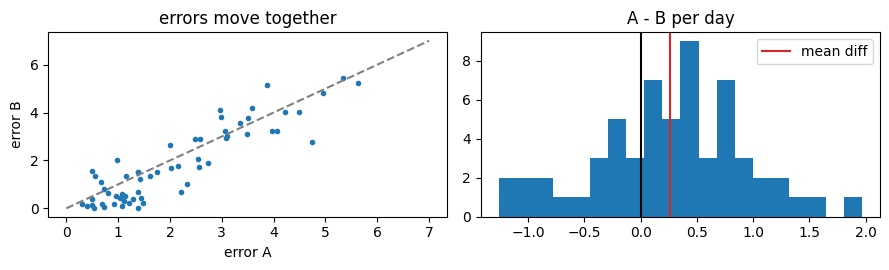

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
ax[0].plot(err_A, err_B, "o", ms=3); ax[0].plot([0, 7], [0, 7], "--", color="grey"); ax[0].set_xlabel("error A"); ax[0].set_ylabel("error B"); ax[0].set_title("errors move together")
ax[1].hist(d, bins=20); ax[1].axvline(0, color="k"); ax[1].axvline(d.mean(), color="tab:red", label="mean diff"); ax[1].set_title("A - B per day"); ax[1].legend()
plt.tight_layout()

## 10. Regression coefficient and correlation

Regression slope: $t = \hat b / \text{SE}(\hat b)$ with $n-2$ df (derived in
`00_stats_intro`, Part E). Correlation: the same test in disguise, because in a simple
regression $t_{\text{slope}} = r\sqrt{n-2}/\sqrt{1-r^2}$.

In [16]:
x = rng.normal(0, 1, 50)
y = 0.4 * x + rng.normal(0, 1, 50)
lr = stats.linregress(x, y)
t_slope = lr.slope / lr.stderr
r_xy = np.corrcoef(x, y)[0, 1]
t_corr = r_xy * np.sqrt(50 - 2) / np.sqrt(1 - r_xy ** 2)
print("slope t :", round(t_slope, 4), " p:", round(lr.pvalue, 4))
print("corr  t :", round(t_corr, 4), " p:", round(2 * stats.t.sf(abs(t_corr), 48), 4), "  scipy pearsonr p:", round(stats.pearsonr(x, y).pvalue, 4))

slope t : 2.6996  p: 0.0096
corr  t : 2.6996  p: 0.0096   scipy pearsonr p: 0.0096


Same $t$, same p-value. "Is the correlation significant?" and "is the slope nonzero?"
are one question.

## 11. Non-normal data: how small can $n$ be?

The $t$ distribution is exact for normal data. For skewed or heavy-tailed data the
central limit theorem takes over as $n$ grows. Measure the false-positive rate of the
one-sample test at 5% for three populations and several $n$.

In [17]:
def fp_rate(draw, n, sims=4000):
    x = draw((sims, n))
    x = x - x.mean()                                   # centre so H0 (mean 0) is true
    t = x.mean(axis=1) / (x.std(axis=1, ddof=1) / np.sqrt(n))
    return (np.abs(t) > stats.t.ppf(0.975, n - 1)).mean()

pops = {
    "normal":            lambda size: rng.normal(0, 1, size),
    "lognormal (skewed)": lambda size: rng.lognormal(0, 1, size),
    "t3 (heavy tails)":  lambda size: rng.standard_t(3, size),
}
rows = []
for name, draw in pops.items():
    for n_ in [5, 10, 30, 100, 500]:
        rows.append({"population": name, "n": n_, "false-positive rate": fp_rate(draw, n_)})
pd.DataFrame(rows).pivot(index="n", columns="population", values="false-positive rate").round(3)

population,lognormal (skewed),normal,t3 (heavy tails)
n,,,
5,0.174,0.055,0.032
10,0.165,0.050,0.040
30,0.112,0.046,0.046
100,0.084,0.050,0.048
500,0.062,0.046,0.051


Heavy tails are forgiving (the test becomes conservative). Skew is the problem: with
lognormal data at $n = 10$ the test rejects far more than 5%, and it takes a few hundred
points to settle. Look at a histogram before trusting a small-sample $t$.

## 12. Autocorrelation: the assumption that fails most on time series

If observations are correlated, $s/\sqrt n$ is the wrong standard error. For lag-1
autocorrelation $\rho$ the variance of the mean is inflated by roughly
$(1+\rho)/(1-\rho)$; equivalently the effective sample size is $n(1-\rho)/(1+\rho)$.
Simulate the false-positive rate of the naive test on AR(1) series with true mean 0.

In [18]:
def ar1_batch(phi, n, sims):
    out = np.zeros((sims, n))
    eps = rng.normal(0, 1, (sims, n))
    for t in range(1, n):
        out[:, t] = phi * out[:, t - 1] + eps[:, t]
    return out

rows = []
for phi in [0.0, 0.3, 0.6, 0.8, 0.9]:
    x = ar1_batch(phi, 300, 3000)
    t_naive = x.mean(axis=1) / (x.std(axis=1, ddof=1) / np.sqrt(300))
    xc = x - x.mean(axis=1, keepdims=True)
    rho1 = (xc[:, 1:] * xc[:, :-1]).sum(axis=1) / (xc ** 2).sum(axis=1)
    t_corr = t_naive / np.sqrt((1 + rho1) / (1 - rho1))
    rows.append({"phi": phi, "naive FP rate": (np.abs(t_naive) > 1.96).mean(), "corrected FP rate": (np.abs(t_corr) > 1.96).mean(),
                 "n_eff of 300": 300 * (1 - phi) / (1 + phi)})
pd.DataFrame(rows).round(3)

,phi,naive FP rate,corrected FP rate,n_eff of 300
0,0.0,0.053,0.054,300.000
1,0.3,0.170,0.066,161.538
2,0.6,0.319,0.055,75.000
3,0.8,0.519,0.073,33.333
4,0.9,0.662,0.088,15.789


Three practical fixes, from crude to careful:

1. **Aggregate** to a frequency where autocorrelation is small (hourly → daily → weekly means), then use the ordinary test on fewer points.
2. **Effective sample size**: multiply the SE by $\sqrt{(1+\rho_1)/(1-\rho_1)}$.
3. **Newey–West** standard errors, or a **block bootstrap**.

The first is the one you can do in an interview in one line, and it makes the
assumption visible: "I aggregate to weekly because daily consumption has lag-1
autocorrelation 0.9".

## 13. The Sharpe ratio is a $t$-statistic

For returns $r_1..r_T$ the Sharpe ratio is $\text{SR} = \bar r / s$, so

$$t = \frac{\bar r}{s/\sqrt T} = \text{SR}\sqrt{T}$$

An annualised Sharpe $\text{SR}_a$ over $Y$ years gives $t \approx \text{SR}_a\sqrt{Y}$
(the $\sqrt{252}$ factors cancel). Two years at Sharpe 1.5 is $t = 2.1$: barely
significant, and that is before autocorrelation, fat tails and the number of strategies
you tried.

In [19]:
rows = []
for sr in [0.5, 1.0, 1.5, 2.0, 3.0]:
    for years in [1, 2, 3, 5, 10]:
        rows.append({"annual Sharpe": sr, "years": years, "t": sr * np.sqrt(years)})
pd.DataFrame(rows).pivot(index="annual Sharpe", columns="years", values="t").round(2)

years,1,2,3,5,10
annual Sharpe,,,,,
0.5,0.5,0.71,0.87,1.12,1.58
1.0,1.0,1.41,1.73,2.24,3.16
1.5,1.5,2.12,2.60,3.35,4.74
2.0,2.0,2.83,3.46,4.47,6.32
3.0,3.0,4.24,5.20,6.71,9.49


In [20]:
daily = rng.normal(1.5 / np.sqrt(252), 1.0, 252 * 2)      # 2 years of daily returns, annual Sharpe 1.5, daily sd 1
sr_daily = daily.mean() / daily.std(ddof=1)
print("annualised Sharpe:", round(sr_daily * np.sqrt(252), 3))
print("t = SR_daily * sqrt(T):", round(sr_daily * np.sqrt(len(daily)), 3))
print("scipy one-sample t    :", round(stats.ttest_1samp(daily, 0).statistic, 3))

annualised Sharpe: 1.793
t = SR_daily * sqrt(T): 2.536
scipy one-sample t    : 2.536


# Part 3 — Real data

Hourly power data, 2022–2023: consumption, temperature, wind, price. Five questions,
one $t$-test each, with the assumption check that each one needs.

In [21]:
df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
day = df.resample("D").mean()
day["dow"] = day.index.dayofweek
print(df.shape, day.shape)
day.head(3).round(2)

(17520, 5) (730, 6)


,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh,dow
time,,,,,,
2022-01-01 00:00:00+00:00,30587.24,1.75,7.27,19.87,98.25,5
2022-01-02 00:00:00+00:00,30374.75,3.16,8.93,20.90,87.57,6
2022-01-03 00:00:00+00:00,31855.71,3.41,12.37,18.97,75.32,0


### 14.1 One-sample: is the mean **daily** price change positive?

Daily average prices, differenced. Check autocorrelation of the differences first, then
test.

In [22]:
dp = day["price_eur_mwh"].diff().dropna().to_numpy()
dc = dp - dp.mean()
rho1 = (dc[1:] * dc[:-1]).sum() / (dc ** 2).sum()
t_naive = dp.mean() / (dp.std(ddof=1) / np.sqrt(len(dp)))
t_corr = t_naive / np.sqrt((1 + rho1) / (1 - rho1))
print("n:", len(dp), " mean daily change:", round(dp.mean(), 3), " sd:", round(dp.std(ddof=1), 2))
print("lag-1 autocorrelation:", round(rho1, 3))
print("naive t:", round(t_naive, 3), " corrected t:", round(t_corr, 3), " one-sided p (naive):", round(stats.t.sf(t_naive, len(dp) - 1), 3))

n: 729  mean daily change: -0.006  sd: 14.22
lag-1 autocorrelation: -0.163
naive t: -0.011  corrected t: -0.012  one-sided p (naive): 0.504


Nothing there, and the negative autocorrelation means the naive $t$ was, if anything,
too small. Prices fell over the two years (mean change negative) but not at a rate the
day-to-day noise can distinguish from zero.

### 14.2 Two-sample: weekday vs weekend consumption

Daily means, Welch's test. But daily consumption is autocorrelated (ask before testing).

In [23]:
wd = day.loc[day["dow"] < 5, "consumption_mwh"].to_numpy()
we = day.loc[day["dow"] >= 5, "consumption_mwh"].to_numpy()
print("weekday n:", len(wd), " mean:", round(wd.mean(), 0), "   weekend n:", len(we), " mean:", round(we.mean(), 0))
print("difference:", round(wd.mean() - we.mean(), 0), "MWh/h")
print("Welch:", stats.ttest_ind(wd, we, equal_var=False))
c = day["consumption_mwh"].to_numpy(); cc = c - c.mean()
print("lag-1 autocorrelation of daily consumption:", round((cc[1:] * cc[:-1]).sum() / (cc ** 2).sum(), 3))

weekday n: 520  mean: 29914.0    weekend n: 210  mean: 27832.0
difference: 2082.0 MWh/h
Welch: TtestResult(statistic=12.836612548018103, pvalue=8.222261706395646e-32, df=398.8840452375371)
lag-1 autocorrelation of daily consumption: 0.805


The effect is large (about 2,000 MWh/h) and the naive $t$ is far beyond any threshold,
so the conclusion survives any reasonable correction. Still, do the honest version: the
autocorrelation comes from weather, which affects weekdays and weekends alike. Compare
each weekend with the weekdays of the **same week** (a paired test on weekly
differences), which removes the weather and the trend.

In [24]:
wk = day["consumption_mwh"].groupby([day.index.isocalendar().year, day.index.isocalendar().week, day["dow"] >= 5]).mean().unstack()
wk.columns = ["weekday", "weekend"]
wk = wk.dropna()
dwk = (wk["weekday"] - wk["weekend"]).to_numpy()
print("weeks:", len(dwk), " mean within-week difference:", round(dwk.mean(), 0), " sd:", round(dwk.std(ddof=1), 0))
print("paired t:", round(dwk.mean() / (dwk.std(ddof=1) / np.sqrt(len(dwk))), 2))
dwc = dwk - dwk.mean()
print("lag-1 autocorrelation of the weekly differences:", round((dwc[1:] * dwc[:-1]).sum() / (dwc ** 2).sum(), 3), " <- small: the paired test is on safe ground")

weeks: 104  mean within-week difference: 2108.0  sd: 831.0
paired t: 25.88
lag-1 autocorrelation of the weekly differences: -0.159  <- small: the paired test is on safe ground


### 14.3 Paired: is the "same hour last week" forecast better than "same hour yesterday"?

Two naive forecasts of hourly consumption, evaluated as mean absolute error per day.
Same days for both, so paired.

In [25]:
cons = df["consumption_mwh"]
err24 = (cons - cons.shift(24)).abs().resample("D").mean()
err168 = (cons - cons.shift(168)).abs().resample("D").mean()
both = pd.concat([err24.rename("lag24"), err168.rename("lag168")], axis=1).dropna()
dd = (both["lag24"] - both["lag168"]).to_numpy()
print("days:", len(dd), " mean MAE lag24:", round(both["lag24"].mean(), 0), " lag168:", round(both["lag168"].mean(), 0))
print("mean daily difference (lag24 - lag168):", round(dd.mean(), 1), " sd:", round(dd.std(ddof=1), 1))
print("paired t:", round(stats.ttest_rel(both["lag24"], both["lag168"]).statistic, 2))
ddc = dd - dd.mean()
rho = (ddc[1:] * ddc[:-1]).sum() / (ddc ** 2).sum()
print("lag-1 autocorrelation of the differences:", round(rho, 3), " -> corrected t:", round(stats.ttest_rel(both["lag24"], both["lag168"]).statistic / np.sqrt((1 + rho) / (1 - rho)), 2))

days: 723  mean MAE lag24: 1372.0  lag168: 1221.0
mean daily difference (lag24 - lag168): 150.5  sd: 922.6
paired t: 4.39
lag-1 autocorrelation of the differences: 0.004  -> corrected t: 4.37


The weekly-lag forecast wins by a wide, reliable margin (the weekend effect is what
`lag24` gets wrong on Mondays and Saturdays). This is the Diebold–Mariano idea: a
paired $t$-test on a loss difference, with an autocorrelation-aware SE.

### 14.4 Regression coefficient: the temperature effect

Daily consumption on heating degrees, 2022 only. $t$ for the slope, then the same after
correcting for residual autocorrelation.

In [26]:
d22 = day.loc["2022"]
hdd = np.clip(15 - d22["temp_c"], 0, None).to_numpy()
y = d22["consumption_mwh"].to_numpy()
lr = stats.linregress(hdd, y)
e = y - (lr.intercept + lr.slope * hdd); ec = e - e.mean()
rho_e = (ec[1:] * ec[:-1]).sum() / (ec ** 2).sum()
print("slope:", round(lr.slope, 1), "MWh/h per degree   SE:", round(lr.stderr, 1), "  t:", round(lr.slope / lr.stderr, 1))
print("residual lag-1 autocorrelation:", round(rho_e, 3), "  effective-n corrected t:", round(lr.slope / lr.stderr / np.sqrt((1 + rho_e) / (1 - rho_e)), 1))

slope: 365.6 MWh/h per degree   SE: 10.7   t: 34.3
residual lag-1 autocorrelation: 0.267   effective-n corrected t: 26.1


### 14.5 Correlation: wind speed and price

Wind pushes price down (more zero-marginal-cost generation). First the naive daily
correlation and its $t$; then what happens if you "fix autocorrelation" by aggregating
to weeks; then the honest version.

In [27]:
def corr_t(a, b):
    r = np.corrcoef(a, b)[0, 1]
    return r, r * np.sqrt(len(a) - 2) / np.sqrt(1 - r ** 2)

r_d, t_d = corr_t(day["wind_ms"], day["price_eur_mwh"])
week = df.resample("W").mean()
r_w, t_w = corr_t(week["wind_ms"], week["price_eur_mwh"])
print("daily levels : r =", round(r_d, 3), " t =", round(t_d, 2), " n =", len(day))
print("weekly means : r =", round(r_w, 3), " t =", round(t_w, 2), " n =", len(week), " <- the effect vanished?")

daily levels : r = -0.332  t = -9.5  n = 730
weekly means : r = -0.097  t = -0.99  n = 105  <- the effect vanished?


Aggregating to weeks did not make the test honest, it made it blind. Weekly price
variation is dominated by the slow gas-price regime of 2022, which has nothing to do
with wind; the wind effect lives at the daily scale. The problem with the daily test is
not only autocorrelation, it is a **confounder** (the price level). Remove it: subtract
each week's mean from both series, so only within-week variation remains, then test.

In [28]:
wk_key = [day.index.isocalendar().year, day.index.isocalendar().week]
wind_dm = day["wind_ms"] - day["wind_ms"].groupby(wk_key).transform("mean")
price_dm = day["price_eur_mwh"] - day["price_eur_mwh"].groupby(wk_key).transform("mean")
r_dm, t_dm = corr_t(wind_dm, price_dm)
u = (wind_dm * price_dm).to_numpy(); uc = u - u.mean()
rho_u = (uc[1:] * uc[:-1]).sum() / (uc ** 2).sum()
t_dm_corr = t_dm / np.sqrt((1 + rho_u) / (1 - rho_u))
print("within-week demeaned daily: r =", round(r_dm, 3), " t =", round(t_dm, 2))
print("lag-1 autocorrelation of the product terms:", round(rho_u, 3), " -> corrected t:", round(t_dm_corr, 2))

within-week demeaned daily: r = -0.759  t = -31.48
lag-1 autocorrelation of the product terms: 0.108  -> corrected t: -28.26


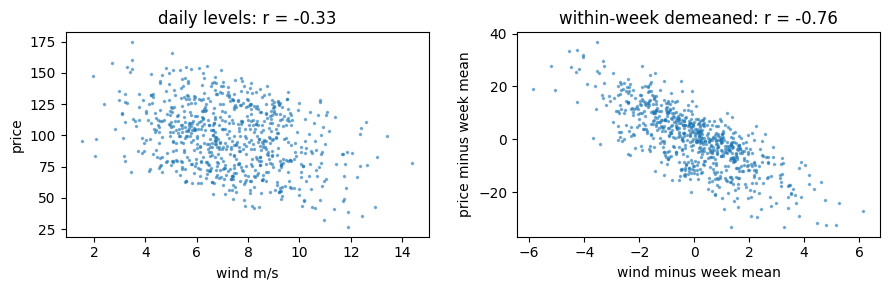

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(day["wind_ms"], day["price_eur_mwh"], ".", ms=3, alpha=.5); ax[0].set_title(f"daily levels: r = {r_d:.2f}"); ax[0].set_xlabel("wind m/s"); ax[0].set_ylabel("price")
ax[1].plot(wind_dm, price_dm, ".", ms=3, alpha=.5); ax[1].set_title(f"within-week demeaned: r = {r_dm:.2f}"); ax[1].set_xlabel("wind minus week mean"); ax[1].set_ylabel("price minus week mean")
plt.tight_layout()

Once the price level is removed the relationship is tight ($r \approx -0.76$), the
product terms are only weakly autocorrelated, and the corrected $t$ is far from zero.
Same data, three answers ($t = -9.5$, $-1$, $-28$); the third is the one that matches
the physics and the assumptions.

### 14.6 Summary

In [30]:
pd.DataFrame([
    {"question": "mean daily price change > 0?", "test": "one-sample", "t": t_corr, "verdict": "no evidence"},
    {"question": "weekday vs weekend consumption", "test": "paired by week", "t": dwk.mean() / (dwk.std(ddof=1) / np.sqrt(len(dwk))), "verdict": "strong"},
    {"question": "lag168 beats lag24 forecast", "test": "paired (DM-style), AR-corrected", "t": stats.ttest_rel(both["lag24"], both["lag168"]).statistic / np.sqrt((1 + rho) / (1 - rho)), "verdict": "strong"},
    {"question": "temperature slope != 0", "test": "regression, AR-corrected", "t": lr.slope / lr.stderr / np.sqrt((1 + rho_e) / (1 - rho_e)), "verdict": "strong"},
    {"question": "wind–price correlation != 0", "test": "within-week demeaned, AR-corrected", "t": t_dm_corr, "verdict": "strong"},
]).round(2)

,question,test,t,verdict
0,mean daily price change > 0?,one-sample,-0.01,no evidence
1,weekday vs weekend consumption,paired by week,25.88,strong
2,lag168 beats lag24 forecast,"paired (DM-style), AR-corrected",4.37,strong
3,temperature slope != 0,"regression, AR-corrected",26.06,strong
4,wind–price correlation != 0,"within-week demeaned, AR-corrected",-28.26,strong


## Quick reference

- $t = (\hat\theta - \theta_0)/\widehat{\text{SE}}$; under $H_0$ and the assumptions, $t \sim t_\nu$.
- $t_\nu = Z/\sqrt{V/\nu}$ with $Z \sim N(0,1)$, $V \sim \chi^2_\nu$ independent; tails heavier than normal, $\to$ normal as $\nu \to \infty$.
- df = $n$ minus the number of parameters estimated before the residuals.
- p two-sided `2*stats.t.sf(abs(t), df)`; one-sided `stats.t.sf(t, df)`; decide which **before** looking.
- one-sample `ttest_1samp`, paired `ttest_rel`, two-sample `ttest_ind(equal_var=False)`, slope `linregress`, correlation `pearsonr`.
- Power: for effect $d$ (in sd units), $n \approx (2.5/d)^2$ for 80% power at 5% one-sided.
- Sharpe: $t = \text{SR}_{\text{annual}}\sqrt{\text{years}}$.
- Before any $t$ on time series: lag-1 autocorrelation. If it is not near zero, aggregate, correct by $\sqrt{(1+\rho)/(1-\rho)}$, or use Newey–West.
- Compare models on the same days with a **paired** test on the loss difference.

Related: `03_scipy/00` (SEs and autocorrelation in depth), `03_scipy/04` (power, multiple comparisons, permutation tests), `05_time_series_research/02` (Diebold–Mariano and evaluation).